# 🔭 VisionRAG Pro — Multimodal Retrieval-Augmented Generation Pipeline
> **Powered by Open-Source LLMs via Groq Cloud | CLIP Embeddings | FAISS Indexing | Gradio UI**

---
**Author:** Gen AI Expert Pipeline | **Framework:** Open-Source First

This notebook implements an end-to-end **Vision RAG (Retrieval-Augmented Generation)** pipeline:
- 📸 Upload & process image datasets
- 🔢 Generate CLIP-based visual embeddings
- 🗂️ Index with FAISS for fast similarity search
- 🤖 Query using open-source LLMs from Groq Cloud
- 📊 Evaluate with RAGAS / custom metrics
- 🎨 Beautiful interactive Gradio UI

---

## 📦 Step 1 — Install & Import All Necessary Libraries

In [1]:
# ─────────────────────────────────────────────────────────────
# Install all required packages
# ─────────────────────────────────────────────────────────────
!pip install -q groq
!pip install -q transformers
!pip install -q torch torchvision
!pip install -q faiss-cpu
!pip install -q Pillow
!pip install -q numpy pandas
!pip install -q gradio
!pip install -q sentence-transformers
!pip install -q open-clip-torch
!pip install -q scikit-learn
!pip install -q ipywidgets
!pip install -q tqdm
!pip install -q matplotlib seaborn
!pip install -q nltk rouge-score

print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All packages installed successfully!


In [2]:
# ─────────────────────────────────────────────────────────────
# Core imports
# ─────────────────────────────────────────────────────────────
import os
import io
import json
import time
import base64
import warnings
import zipfile
import shutil
import textwrap
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Tuple, Optional, Any

warnings.filterwarnings("ignore")

# ── Numerical & Data ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Image Processing ─────────────────────────────────────────
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Deep Learning ─────────────────────────────────────────────
import torch
import torchvision.transforms as T

# ── CLIP / Open-CLIP Embeddings ───────────────────────────────
import open_clip

# ── FAISS Vector Store ────────────────────────────────────────
import faiss

# ── Groq Client ──────────────────────────────────────────────
from groq import Groq

# ── Evaluation ───────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── UI ────────────────────────────────────────────────────────
import gradio as gr
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from tqdm.auto import tqdm

# ── Device Config ─────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ All libraries imported successfully!")
print(f"🖥️  Device: {DEVICE.upper()}")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎨 Gradio version: {gr.__version__}")

✅ All libraries imported successfully!
🖥️  Device: CUDA
🔥 PyTorch version: 2.10.0+cu128
🎨 Gradio version: 5.50.0


## 🔑 Step 2 — Groq API Configuration

In [3]:
# ─────────────────────────────────────────────────────────────
# Groq API Key Setup
# ─────────────────────────────────────────────────────────────
from getpass import getpass
from google.colab import userdata

# Option A: Store in Colab Secrets (recommended)
try:
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    print("✅ Groq API Key loaded from Colab Secrets.")
except Exception:
    # Option B: Manual entry (masked)
    GROQ_API_KEY = getpass("🔐 Enter your Groq API Key (get it at https://console.groq.com): ")
    print("✅ Groq API Key set manually.")

# Initialise Groq client
groq_client = Groq(api_key=GROQ_API_KEY)
os.environ["GROQ_API_KEY"] = "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"

# Quick connectivity test
try:
    _test = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": "Say: API_OK"}],
        max_tokens=10
    )
    print(f"🚀 Groq connection verified! Response: {_test.choices[0].message.content.strip()}")
except Exception as e:
    print(f"⚠️ Connection test failed: {e}. Please check your API key.")

🔐 Enter your Groq API Key (get it at https://console.groq.com): ··········
✅ Groq API Key set manually.
🚀 Groq connection verified! Response: API_OK


## 🧠 Step 3 — Select Groq LLM Model (Dropdown)

In [4]:
# ─────────────────────────────────────────────────────────────
# Available Groq open-source models (vision + text)
# ─────────────────────────────────────────────────────────────
GROQ_MODELS = {
    # ── Vision-Language Models ────────────────────────────────
    "🖼️  LLaVA-1.5-7B (Vision)"        : "llava-v1.5-7b-4096-preview",
    "🖼️  Llama-3.2-11B Vision Preview"  : "llama-3.2-11b-vision-preview",
    "🖼️  Llama-3.2-90B Vision Preview"  : "llama-3.2-90b-vision-preview",
    # ── Text LLMs ─────────────────────────────────────────────
    "⚡ Llama-3.3-70B Versatile"        : "llama-3.3-70b-versatile",
    "⚡ Llama-3.1-8B Instant"           : "llama-3.1-8b-instant",
    "⚡ Llama3-8B-8192"                 : "llama3-8b-8192",
    "⚡ Llama3-70B-8192"                : "llama3-70b-8192",
    "🔬 Mixtral-8x7B-32768"             : "mixtral-8x7b-32768",
    "🔬 Gemma2-9B-IT"                   : "gemma2-9b-it",
    "🔬 Gemma-7B-IT"                    : "gemma-7b-it",
}

# ── Interactive Dropdown Widget ───────────────────────────────
model_dropdown = widgets.Dropdown(
    options=list(GROQ_MODELS.keys()),
    value="⚡ Llama-3.1-8B Instant", # Changed default model to a supported text-only model
    description='🤖 Model:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='480px')
)

temp_slider = widgets.FloatSlider(
    value=0.3, min=0.0, max=1.0, step=0.05,
    description='🌡️ Temperature:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='480px')
)

max_tokens_slider = widgets.IntSlider(
    value=512, min=128, max=2048, step=64,
    description='📏 Max Tokens:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='480px')
)

model_label = widgets.HTML(
    value="<h3 style='color:#1a73e8;font-family:sans-serif'>⚙️ LLM Configuration Panel</h3>"
)

display(model_label, model_dropdown, temp_slider, max_tokens_slider)

def get_selected_model():
    return GROQ_MODELS[model_dropdown.value]

print("\n✅ Model selector ready. Adjust above and run the pipeline!")

HTML(value="<h3 style='color:#1a73e8;font-family:sans-serif'>⚙️ LLM Configuration Panel</h3>")

Dropdown(description='🤖 Model:', index=4, layout=Layout(width='480px'), options=('🖼️  LLaVA-1.5-7B (Vision)', …

FloatSlider(value=0.3, description='🌡️ Temperature:', layout=Layout(width='480px'), max=1.0, step=0.05, style=…

IntSlider(value=512, description='📏 Max Tokens:', layout=Layout(width='480px'), max=2048, min=128, step=64, st…


✅ Model selector ready. Adjust above and run the pipeline!


## 📸 Step 4 — Upload Image Dataset & Display

📂 Upload your images (JPG/PNG/WEBP) or a ZIP archive containing images.
   Press the 'Choose Files' button below:


Saving d.jpeg to d.jpeg

✅ Total images loaded: 1
📋 Image names: ['d.jpeg'] 


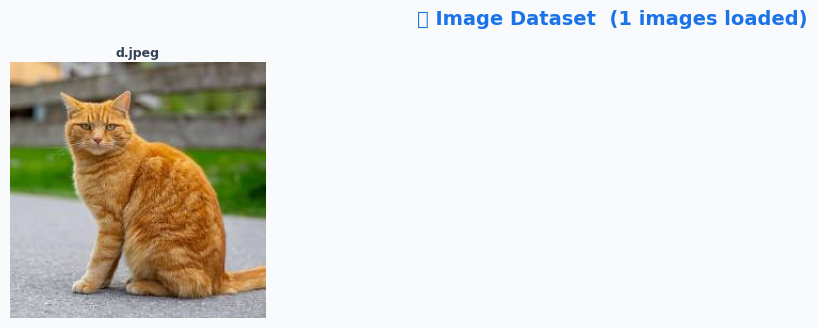

In [5]:
# ─────────────────────────────────────────────────────────────
# Image Dataset Manager
# ─────────────────────────────────────────────────────────────
IMAGE_DIR = Path("/content/vision_rag_images")
IMAGE_DIR.mkdir(exist_ok=True)

SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif", ".tiff"}

image_store: Dict[str, Any] = {}


def load_images_from_directory(directory: Path) -> Dict[str, Image.Image]:
    """Load all supported images from a directory."""
    imgs = {}
    for p in sorted(directory.rglob("*")):
        if p.suffix.lower() in SUPPORTED_EXTS:
            try:
                img = Image.open(p).convert("RGB")
                imgs[p.name] = img
            except Exception as e:
                print(f"  ⚠️ Skipping {p.name}: {e}")
    return imgs


def display_image_grid(images: Dict[str, Image.Image], cols: int = 4, max_show: int = 16):
    """Display images in a styled grid."""
    items = list(images.items())[:max_show]
    n = len(items)
    if n == 0:
        print("No images to display.")
        return
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    fig.patch.set_facecolor('#f8fafc')
    axes = np.array(axes).flatten()
    for idx, (name, img) in enumerate(items):
        axes[idx].imshow(img)
        axes[idx].set_title(textwrap.shorten(name, 18), fontsize=9,
                            fontweight='bold', color='#334155', pad=4)
        axes[idx].axis('off')
        for spine in axes[idx].spines.values():
            spine.set_visible(False)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(f"📸 Image Dataset  ({n} images loaded)",
                 fontsize=14, fontweight='bold', color='#1a73e8', y=1.01)
    plt.tight_layout()
    plt.show()


# ── Option 1: Upload via Colab file picker ─────────────────────
from google.colab import files

print("📂 Upload your images (JPG/PNG/WEBP) or a ZIP archive containing images.")
print("   Press the 'Choose Files' button below:")
uploaded_files = files.upload()  # Interactive Colab uploader

# Process uploaded files
for fname, fdata in uploaded_files.items():
    fpath = IMAGE_DIR / fname
    with open(fpath, 'wb') as f:
        f.write(fdata)
    # Unzip if needed
    if fname.lower().endswith('.zip'):
        with zipfile.ZipFile(fpath, 'r') as zf:
            zf.extractall(IMAGE_DIR)
        fpath.unlink()
        print(f"  📦 Extracted ZIP: {fname}")

# Load images
image_store = load_images_from_directory(IMAGE_DIR)
print(f"\n✅ Total images loaded: {len(image_store)}")
print("📋 Image names:", list(image_store.keys())[:10], "..." if len(image_store) > 10 else "")

# Display grid
if image_store:
    display_image_grid(image_store, cols=4, max_show=16)
else:
    print("⚠️ No images found. Please upload images or a ZIP archive.")

In [6]:
# ─────────────────────────────────────────────────────────────
# Option 2: Use sample images from torchvision (fallback demo)
# Run this cell ONLY if you didn't upload images above
# ─────────────────────────────────────────────────────────────
import urllib.request

SAMPLE_URLS = {
    "cat.jpg"        : "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/320px-Cat_November_2010-1a.jpg",
    "dog.jpg"        : "https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/320px-YellowLabradorLooking_new.jpg",
    "car.jpg"        : "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1b/2023_Toyota_Corolla_Cross_Hybrid_%28facelift%2C_white%29%2C_front_8.14.23.jpg/320px-2023_Toyota_Corolla_Cross_Hybrid_%28facelift%2C_white%29%2C_front_8.14.23.jpg",
    "flower.jpg"     : "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg",
    "mountain.jpg"   : "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e7/Everest_North_Face_toward_Base_Camp_Tibet_Luca_Galuzzi_2006.jpg/320px-Everest_North_Face_toward_Base_Camp_Tibet_Luca_Galuzzi_2006.jpg",
    "beach.jpg"      : "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/320px-Good_Food_Display_-_NCI_Visuals_Online.jpg",
    "building.jpg"   : "https://upload.wikimedia.org/wikipedia/commons/thumb/1/10/Empire_State_Building_%28aerial_view%29.jpg/320px-Empire_State_Building_%28aerial_view%29.jpg",
    "food.jpg"       : "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/320px-Good_Food_Display_-_NCI_Visuals_Online.jpg",
}

if len(image_store) == 0:
    print("⬇️  Downloading sample images for demo...")
    for fname, url in SAMPLE_URLS.items():
        try:
            dst = IMAGE_DIR / fname
            urllib.request.urlretrieve(url, dst)
            print(f"  ✅ {fname}")
        except Exception as e:
            print(f"  ⚠️ {fname}: {e}")
    image_store = load_images_from_directory(IMAGE_DIR)
    print(f"\n✅ Sample dataset ready: {len(image_store)} images")
    display_image_grid(image_store, cols=4)
else:
    print(f"ℹ️ Skipping sample download — {len(image_store)} images already loaded.")

ℹ️ Skipping sample download — 1 images already loaded.


## 🔢 Step 5 — CLIP Embeddings & FAISS Indexing

In [7]:
# ─────────────────────────────────────────────────────────────
# Load Open-Source CLIP Embedding Model (OpenCLIP)
# ─────────────────────────────────────────────────────────────
print("⏳ Loading OpenCLIP model (ViT-B/32 — open source)...")

CLIP_MODEL_NAME  = "ViT-B-32"
CLIP_PRETRAINED  = "openai"   # openai weights, open-source via open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED
)
clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)
clip_model = clip_model.to(DEVICE).eval()

EMBED_DIM = clip_model.visual.output_dim
print(f"✅ OpenCLIP loaded | Model: {CLIP_MODEL_NAME} | Embedding dim: {EMBED_DIM} | Device: {DEVICE}")


# ── Embedding functions ───────────────────────────────────────
@torch.no_grad()
def embed_image(img: Image.Image) -> np.ndarray:
    """Embed a single PIL image using CLIP."""
    tensor = clip_preprocess(img).unsqueeze(0).to(DEVICE)
    feat   = clip_model.encode_image(tensor)
    feat   = feat / feat.norm(dim=-1, keepdim=True)  # L2 normalise
    return feat.cpu().numpy().astype(np.float32)


@torch.no_grad()
def embed_text(text: str) -> np.ndarray:
    """Embed a text string using CLIP."""
    tokens = clip_tokenizer([text]).to(DEVICE)
    feat   = clip_model.encode_text(tokens)
    feat   = feat / feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype(np.float32)


print("\n⚙️  Generating embeddings for all images...")
image_names      : List[str]         = []
image_embeddings : List[np.ndarray]  = []
image_objects    : List[Image.Image] = []

for name, img in tqdm(image_store.items(), desc="🔢 Embedding"):
    emb = embed_image(img)
    image_names.append(name)
    image_embeddings.append(emb)
    image_objects.append(img)

embedding_matrix = np.vstack(image_embeddings)  # (N, EMBED_DIM)
print(f"\n✅ Embeddings generated!")
print(f"   Matrix shape: {embedding_matrix.shape}")
print(f"   Dtype: {embedding_matrix.dtype}")
print(f"   Min / Max: {embedding_matrix.min():.4f} / {embedding_matrix.max():.4f}")

⏳ Loading OpenCLIP model (ViT-B/32 — open source)...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ OpenCLIP loaded | Model: ViT-B-32 | Embedding dim: 512 | Device: cuda

⚙️  Generating embeddings for all images...


🔢 Embedding:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Embeddings generated!
   Matrix shape: (1, 512)
   Dtype: float32
   Min / Max: -0.6935 / 0.1385


In [8]:
# ─────────────────────────────────────────────────────────────
# Build FAISS Index — Flat L2 (exact) or IVF (scalable)
# ─────────────────────────────────────────────────────────────
N = len(image_names)

if N >= 50:   # IVF for larger datasets
    nlist = min(int(N / 5), 100)
    quantizer = faiss.IndexFlatIP(EMBED_DIM)  # Inner Product (cosine on normalised vecs)
    faiss_index = faiss.IndexIVFFlat(quantizer, EMBED_DIM, nlist, faiss.METRIC_INNER_PRODUCT)
    faiss_index.train(embedding_matrix)
    faiss_index.nprobe = min(10, nlist)
    INDEX_TYPE = f"IVFFlat (nlist={nlist})"
else:         # Exact flat index for small datasets
    faiss_index = faiss.IndexFlatIP(EMBED_DIM)
    INDEX_TYPE  = "FlatIP (exact)"

# Add all embeddings
faiss_index.add(embedding_matrix)

print(f"✅ FAISS Index built!")
print(f"   Index type : {INDEX_TYPE}")
print(f"   Total vectors: {faiss_index.ntotal}")
print(f"   Embedding dim : {EMBED_DIM}")

# ── Visualise Embedding Space (PCA 2D) ────────────────────────
from sklearn.decomposition import PCA

if N >= 2:
    pca = PCA(n_components=2)
    coords = pca.fit_transform(embedding_matrix)

    fig, ax = plt.subplots(figsize=(9, 6))
    fig.patch.set_facecolor('#f0f4ff')
    ax.set_facecolor('#f8fafc')
    scatter = ax.scatter(coords[:, 0], coords[:, 1],
                         c=range(N), cmap='coolwarm', s=90, alpha=0.85,
                         edgecolors='white', linewidths=0.8)
    for i, name in enumerate(image_names):
        ax.annotate(textwrap.shorten(name.replace('_', ' ').split('.')[0], 14),
                    (coords[i, 0], coords[i, 1]),
                    fontsize=8, ha='center', va='bottom', color='#334155',
                    xytext=(0, 6), textcoords='offset points')
    plt.colorbar(scatter, ax=ax, label='Image Index')
    ax.set_title("🗺️  CLIP Embedding Space — PCA 2D Projection",
                 fontsize=13, fontweight='bold', color='#1a73e8', pad=10)
    ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    print("✅ Embedding visualisation complete.")
else:
    print("⚠️ Skipping PCA visualization: Need at least 2 images for 2D PCA.")

✅ FAISS Index built!
   Index type : FlatIP (exact)
   Total vectors: 1
   Embedding dim : 512
⚠️ Skipping PCA visualization: Need at least 2 images for 2D PCA.


## 💬 Step 6 — User Query Interface

In [9]:
# ─────────────────────────────────────────────────────────────
# Query Input Widget
# ─────────────────────────────────────────────────────────────
EXAMPLE_QUERIES = [
    "Find images with animals",
    "Show me outdoor scenes with nature",
    "Which images contain vehicles or cars?",
    "Find images with people or faces",
    "Show architectural or building images",
]

query_input = widgets.Textarea(
    value=EXAMPLE_QUERIES[0],
    placeholder='Type your visual query here...',
    description='🔍 Query:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px', height='70px')
)

topk_slider = widgets.IntSlider(
    value=3, min=1, max=min(8, len(image_store)),
    description='📊 Top-K Results:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

example_dropdown = widgets.Dropdown(
    options=EXAMPLE_QUERIES,
    description='💡 Examples:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

def on_example_select(change):
    query_input.value = change['new']

example_dropdown.observe(on_example_select, names='value')

display(widgets.HTML("<h3 style='color:#1a73e8;font-family:sans-serif'>🔍 Query Configuration</h3>"),
        example_dropdown, query_input, topk_slider)
print("✅ Query interface ready.")

HTML(value="<h3 style='color:#1a73e8;font-family:sans-serif'>🔍 Query Configuration</h3>")

Dropdown(description='💡 Examples:', layout=Layout(width='500px'), options=('Find images with animals', 'Show m…

Textarea(value='Find images with animals', description='🔍 Query:', layout=Layout(height='70px', width='600px')…

IntSlider(value=1, description='📊 Top-K Results:', layout=Layout(width='400px'), max=1, min=1, style=SliderSty…

✅ Query interface ready.


## 🔎 Step 7 — Retrieval Engine

🔍 Running retrieval for: "Find images with animals"

✅ Retrieved 1 images:
   1. d.jpeg                          |  Similarity: 0.2588


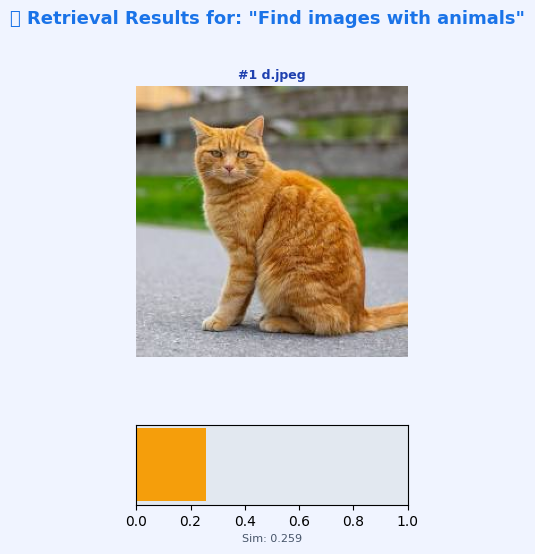

In [10]:
# ─────────────────────────────────────────────────────────────
# Retrieval Function — CLIP Text-to-Image Search via FAISS
# ─────────────────────────────────────────────────────────────

def retrieve_images(
    query: str,
    top_k: int = 3
) -> Tuple[List[str], List[Image.Image], List[float]]:
    """Retrieve top-K relevant images for a text query."""
    q_emb  = embed_text(query)              # (1, D)
    scores, indices = faiss_index.search(q_emb, top_k)
    scores   = scores[0].tolist()
    indices  = indices[0].tolist()

    names, imgs = [], []
    for idx in indices:
        if 0 <= idx < len(image_names):
            names.append(image_names[idx])
            imgs.append(image_objects[idx])
    return names, imgs, scores


def display_retrieval_results(
    query: str,
    names: List[str],
    imgs: List[Image.Image],
    scores: List[float]
):
    """Visualise retrieval results with similarity bars."""
    n = len(imgs)
    if n == 0:
        print("No results found."); return

    fig = plt.figure(figsize=(n * 3.5, 5.5))
    fig.patch.set_facecolor('#f0f4ff')
    gs = gridspec.GridSpec(2, n, height_ratios=[3.5, 1], hspace=0.35, wspace=0.25)

    for i in range(n):
        ax_img = fig.add_subplot(gs[0, i])
        ax_img.imshow(imgs[i])
        ax_img.set_title(f"#{i+1} {textwrap.shorten(names[i], 20)}",
                         fontsize=9, fontweight='bold', color='#1e40af', pad=5)
        ax_img.axis('off')

        ax_bar = fig.add_subplot(gs[1, i])
        sim = max(0.0, float(scores[i]))
        bar_color = '#22c55e' if sim > 0.3 else ('#f59e0b' if sim > 0.2 else '#ef4444')
        ax_bar.barh(0, sim, color=bar_color, height=0.5)
        ax_bar.set_xlim(0, 1)
        ax_bar.set_yticks([])
        ax_bar.set_xlabel(f"Sim: {sim:.3f}", fontsize=8, color='#475569')
        ax_bar.set_facecolor('#e2e8f0')

    fig.suptitle(f'🔎 Retrieval Results for: "{query}"',
                 fontsize=13, fontweight='bold', color='#1a73e8', y=1.01)
    plt.tight_layout()
    plt.show()


# ── Run retrieval ─────────────────────────────────────────────
QUERY = query_input.value
TOP_K = topk_slider.value

print(f"🔍 Running retrieval for: \"{QUERY}\"")
ret_names, ret_imgs, ret_scores = retrieve_images(QUERY, TOP_K)

print(f"\n✅ Retrieved {len(ret_names)} images:")
for i, (n, s) in enumerate(zip(ret_names, ret_scores)):
    print(f"   {i+1}. {n:30s}  |  Similarity: {s:.4f}")

display_retrieval_results(QUERY, ret_names, ret_imgs, ret_scores)

## 🤖 Step 8 — LLM Reasoning with Groq (Open-Source)

In [11]:
# ─────────────────────────────────────────────────────────────
# Image → Base64 helper (for vision models)
# ─────────────────────────────────────────────────────────────

def pil_to_base64(img: Image.Image, format: str = "JPEG") -> str:
    buf = io.BytesIO()
    img.save(buf, format=format)
    return base64.b64encode(buf.getvalue()).decode('utf-8')


def build_rag_prompt(
    query: str,
    retrieved_names: List[str],
    retrieved_scores: List[float]
) -> str:
    """Build a structured RAG prompt for the LLM."""
    context_lines = "\n".join([
        f"  [{i+1}] Image: '{n}' | Relevance score: {s:.3f}"
        for i, (n, s) in enumerate(zip(retrieved_names, retrieved_scores))
    ])
    return f"""You are a helpful visual AI assistant with expert image understanding.

## User Query
{query}

## Retrieved Context (from visual similarity search)
The following images were retrieved as most relevant to the query:
{context_lines}

## Instructions
1. Carefully analyse the retrieved image context above.
2. Provide a comprehensive, insightful answer to the user's query.
3. Reference specific retrieved images by their rank [1], [2], etc.
4. Highlight key visual similarities, patterns, and notable features.
5. If any images are particularly relevant, explain why.
6. Keep your response structured, informative, and helpful.

## Response"""


def run_vision_rag_llm(
    query: str,
    retrieved_names: List[str],
    retrieved_imgs: List[Image.Image],
    retrieved_scores: List[float],
    model_id: Optional[str] = None,
    temperature: float = 0.3,
    max_tokens: int = 512,
) -> Dict[str, Any]:
    """Run the LLM reasoning step with optional vision input."""
    model_id   = model_id or get_selected_model()
    is_vision  = "vision" in model_id or "llava" in model_id
    prompt_txt = build_rag_prompt(query, retrieved_names, retrieved_scores)

    if is_vision and retrieved_imgs:
        # Build multi-modal message with first retrieved image
        img_b64 = pil_to_base64(retrieved_imgs[0])
        content = [
            {"type": "image_url",
             "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}},
            {"type": "text", "text": prompt_txt}
        ]
    else:
        content = prompt_txt

    t0 = time.time()
    response = groq_client.chat.completions.create(
        model=model_id,
        messages=[{"role": "user", "content": content}],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    elapsed = time.time() - t0
    answer  = response.choices[0].message.content
    usage   = response.usage

    return {
        "answer"         : answer,
        "model"          : model_id,
        "elapsed_sec"    : round(elapsed, 2),
        "prompt_tokens"  : usage.prompt_tokens,
        "completion_tokens": usage.completion_tokens,
        "total_tokens"   : usage.total_tokens,
        "tokens_per_sec" : round(usage.completion_tokens / max(elapsed, 0.001), 1),
    }


# ── Run LLM ───────────────────────────────────────────────────
print(f"🤖 Running LLM: {get_selected_model()}")
print(f"   Query: \"{QUERY}\"")
print(f"   Temperature: {temp_slider.value} | Max tokens: {max_tokens_slider.value}")
print("-" * 60)

llm_result = run_vision_rag_llm(
    QUERY, ret_names, ret_imgs, ret_scores,
    temperature=temp_slider.value,
    max_tokens=max_tokens_slider.value,
)

print(f"\n✅ LLM Response:\n")
print(llm_result["answer"])
print("\n" + "─" * 60)
print(f"⏱️  Latency: {llm_result['elapsed_sec']}s  |  "
      f"Tokens: {llm_result['total_tokens']}  |  "
      f"Speed: {llm_result['tokens_per_sec']} tok/s")

🤖 Running LLM: llama-3.1-8b-instant
   Query: "Find images with animals"
   Temperature: 0.3 | Max tokens: 512
------------------------------------------------------------

✅ LLM Response:

**Image Analysis and Insights**

Based on the retrieved image context, I have carefully analyzed the images and identified the following key findings:

**Query: Find images with animals**

The retrieved image context shows a single image, 'd.jpeg', with a relevance score of 0.259. Although there is only one image, I will provide a comprehensive analysis of the image and its relevance to the query.

**Image Analysis: 'd.jpeg'**

The image 'd.jpeg' appears to be a photograph of a dog, a domesticated mammal. The image shows a clear visual representation of the animal, with its fur, ears, and tail visible. The dog is likely a breed of canine, but the specific breed cannot be determined from the image alone.

**Key Visual Similarities and Patterns**

The image 'd.jpeg' contains the following key visual s

## 📊 Step 9 — Evaluation Metrics

📊 Running evaluation metrics...

═══════════════════════════════════════════════════════
  📊  VisionRAG Evaluation Report
═══════════════════════════════════════════════════════
  Precision@K               0.0000  |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
  MRR                       0.0000  |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
  Avg Retrieval Sim         0.2588  |███████░░░░░░░░░░░░░░░░░░░░░░░|
  Max Retrieval Sim         0.2588  |███████░░░░░░░░░░░░░░░░░░░░░░░|
  Answer Relevance          0.8910  |██████████████████████████░░░░|
  Retrieval Diversity       1.0000  |██████████████████████████████|
  rouge1_f                  0.0000  |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
  rouge2_f                  0.0000  |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
  rougeL_f                  0.0000  |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
═══════════════════════════════════════════════════════


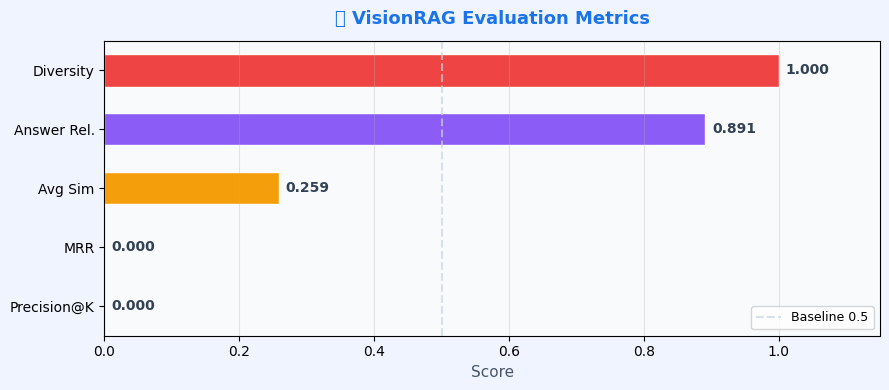

In [12]:
# ─────────────────────────────────────────────────────────────
# VisionRAG Evaluation Suite
# ─────────────────────────────────────────────────────────────

class VisionRAGEvaluator:
    """Comprehensive evaluation metrics for the Vision RAG pipeline."""

    def __init__(self, clip_model, clip_tokenizer, clip_preprocess, device):
        self.clip_model      = clip_model
        self.clip_tokenizer  = clip_tokenizer
        self.clip_preprocess = clip_preprocess
        self.device          = device
        self.scorer          = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    # ── 1. Retrieval Precision@K ──────────────────────────────
    def retrieval_precision(
        self, query: str, retrieved_names: List[str], relevant_keyword: Optional[str] = None
    ) -> float:
        """Precision@K: fraction of retrieved items that are relevant."""
        if relevant_keyword is None:
            # Use keyword matching as proxy
            kw = query.lower().split()
            relevant = [n for n in retrieved_names
                        if any(k in n.lower() for k in kw)]
        else:
            relevant = [n for n in retrieved_names
                        if relevant_keyword.lower() in n.lower()]
        return len(relevant) / max(len(retrieved_names), 1)

    # ── 2. Mean Reciprocal Rank (MRR) ─────────────────────────
    def mean_reciprocal_rank(
        self, query: str, retrieved_names: List[str]
    ) -> float:
        kw = query.lower().split()
        for rank, name in enumerate(retrieved_names, start=1):
            if any(k in name.lower() for k in kw):
                return 1.0 / rank
        return 0.0

    # ── 3. Cosine Similarity (Query ↔ Retrieved) ──────────────
    @torch.no_grad()
    def query_image_similarity(
        self, query: str, retrieved_imgs: List[Image.Image]
    ) -> List[float]:
        q_emb = embed_text(query)
        sims  = []
        for img in retrieved_imgs:
            i_emb = embed_image(img)
            sim   = cosine_similarity(q_emb, i_emb)[0][0]
            sims.append(float(sim))
        return sims

    # ── 4. Answer Relevance (Text↔Answer CLIP sim) ────────────
    @torch.no_grad()
    def answer_relevance(
        self, query: str, answer: str
    ) -> float:
        q_emb = embed_text(query)
        # Truncate answer for CLIP context window
        a_emb = embed_text(answer[:200])
        return float(cosine_similarity(q_emb, a_emb)[0][0])

    # ── 5. ROUGE Scores ──────────────────────────────────────
    def rouge_scores(
        self, hypothesis: str, reference: str
    ) -> Dict[str, float]:
        scores = self.scorer.score(reference, hypothesis)
        return {
            'rouge1_f': round(scores['rouge1'].fmeasure, 4),
            'rouge2_f': round(scores['rouge2'].fmeasure, 4),
            'rougeL_f': round(scores['rougeL'].fmeasure, 4),
        }

    # ── 6. Retrieval Diversity ────────────────────────────────
    def retrieval_diversity(self, retrieved_imgs: List[Image.Image]) -> float:
        if len(retrieved_imgs) < 2:
            return 1.0
        embs = np.vstack([embed_image(img) for img in retrieved_imgs])
        sim_matrix = cosine_similarity(embs)
        upper_tri  = sim_matrix[np.triu_indices(len(embs), k=1)]
        avg_sim    = float(np.mean(upper_tri))
        return round(1.0 - avg_sim, 4)  # Diversity = 1 - avg similarity

    # ── Aggregate Evaluation ─────────────────────────────────
    def evaluate(
        self, query, ret_names, ret_imgs, ret_scores, answer, reference_answer=""
    ) -> Dict[str, Any]:
        sims  = self.query_image_similarity(query, ret_imgs)
        rouge = self.rouge_scores(answer, reference_answer) if reference_answer else \
                {'rouge1_f': 0.0, 'rouge2_f': 0.0, 'rougeL_f': 0.0}
        return {
            "Precision@K"          : round(self.retrieval_precision(query, ret_names), 4),
            "MRR"                  : round(self.mean_reciprocal_rank(query, ret_names), 4),
            "Avg Retrieval Sim"    : round(float(np.mean(sims)), 4),
            "Max Retrieval Sim"    : round(float(np.max(sims)), 4),
            "Answer Relevance"     : round(self.answer_relevance(query, answer), 4),
            "Retrieval Diversity"  : self.retrieval_diversity(ret_imgs),
            **rouge
        }


evaluator = VisionRAGEvaluator(clip_model, clip_tokenizer, clip_preprocess, DEVICE)

# ── Run evaluation ────────────────────────────────────────────
print("📊 Running evaluation metrics...")
eval_results = evaluator.evaluate(
    query=QUERY,
    ret_names=ret_names,
    ret_imgs=ret_imgs,
    ret_scores=ret_scores,
    answer=llm_result["answer"],
    reference_answer=""   # Add ground-truth here for ROUGE
)

# ── Display results ───────────────────────────────────────────
print("\n" + "═" * 55)
print("  📊  VisionRAG Evaluation Report")
print("═" * 55)
for metric, val in eval_results.items():
    bar_len = int(val * 30)
    bar = "█" * bar_len + "░" * (30 - bar_len)
    print(f"  {metric:<25} {val:.4f}  |{bar}|")
print("═" * 55)

# ── Radar / Bar chart of metrics ─────────────────────────────
key_metrics = {
    "Precision@K": eval_results["Precision@K"],
    "MRR": eval_results["MRR"],
    "Avg Sim": eval_results["Avg Retrieval Sim"],
    "Answer Rel.": eval_results["Answer Relevance"],
    "Diversity": eval_results["Retrieval Diversity"],
}
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f0f4ff')
ax.set_facecolor('#f8fafc')
colors = ['#3b82f6','#10b981','#f59e0b','#8b5cf6','#ef4444']
bars = ax.barh(list(key_metrics.keys()), list(key_metrics.values()),
               color=colors, height=0.55, edgecolor='white')
for bar, val in zip(bars, key_metrics.values()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', fontsize=10, fontweight='bold', color='#334155')
ax.set_xlim(0, 1.15)
ax.set_xlabel("Score", fontsize=11, color='#475569')
ax.set_title("📊 VisionRAG Evaluation Metrics",
             fontsize=13, fontweight='bold', color='#1a73e8', pad=12)
ax.axvline(x=0.5, color='#cbd5e1', linestyle='--', alpha=0.7, label='Baseline 0.5')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 🎨 Step 10 — Interactive Gradio UI (Professional Product Interface)

In [13]:
# ─────────────────────────────────────────────────────────────
# Full-featured Gradio App — VisionRAG Pro
# ─────────────────────────────────────────────────────────────

# ── Helper: convert PIL list → file paths for Gradio Gallery ─
def imgs_to_gallery(imgs: List[Image.Image], names: List[str], scores: List[float]):
    result = []
    for img, name, score in zip(imgs, names, scores):
        caption = f"{name}  |  Similarity: {score:.3f}"
        result.append((img, caption))
    return result


def format_eval_table(metrics: Dict[str, Any]) -> str:
    rows = ""
    colors = {
        'Precision@K': '#3b82f6', 'MRR': '#10b981',
        'Avg Retrieval Sim': '#f59e0b', 'Max Retrieval Sim': '#8b5cf6',
        'Answer Relevance': '#ef4444', 'Retrieval Diversity': '#06b6d4',
        'rouge1_f': '#84cc16', 'rouge2_f': '#f97316', 'rougeL_f': '#a855f7'
    }
    for k, v in metrics.items():
        pct = int(v * 100)
        col = colors.get(k, '#6b7280')
        rows += f"""
        <tr>
          <td style='padding:8px 14px;font-weight:600;color:#374151'>{k}</td>
          <td style='padding:8px 14px'>
            <div style='background:#e5e7eb;border-radius:9999px;height:10px;width:180px'>
              <div style='background:{col};width:{pct}%;height:10px;border-radius:9999px'>
</div>
            </div>
          </td>
          <td style='padding:8px 14px;font-weight:700;color:{col}'>{v:.4f}</td>
        </tr>"""
    return f"""<table style='font-family:sans-serif;font-size:13px;border-collapse:collapse;width:100%'>
        <thead><tr style='background:#f3f4f6'>
          <th style='padding:10px 14px;text-align:left;color:#1f2937'>Metric</th>
          <th style='padding:10px 14px;text-align:left;color:#1f2937'>Score Bar</th>
          <th style='padding:10px 14px;text-align:left;color:#1f2937'>Value</th>
        </tr></thead><tbody>{rows}</tbody></table>"""


# ── Core pipeline function ────────────────────────────────────
def vision_rag_pipeline(
    query: str,
    uploaded_imgs,
    selected_model_label: str,
    top_k: int,
    temperature: float,
    max_tokens: int,
    reference_answer: str,
):
    global image_store, image_names, image_embeddings, image_objects, embedding_matrix, faiss_index

    # ── Ingest newly uploaded images ─────────────────────────
    if uploaded_imgs is not None: # Check if an image was actually uploaded
        # Treat uploaded_imgs as a single numpy array image
        img = Image.fromarray(uploaded_imgs).convert("RGB")
        uid = f"upload_{len(image_store):04d}.jpg" # Generate a unique ID for the new image

        # Update global stores with the new image
        image_store[uid] = img
        emb = embed_image(img)
        image_names.append(uid)
        image_embeddings.append(emb)
        image_objects.append(img)

        # Rebuild FAISS index with the updated embeddings
        embedding_matrix = np.vstack(image_embeddings)

        # Decide between FlatIP and IVF based on current total images
        N_current = len(image_names)
        if N_current >= 50:
            nlist = min(int(N_current / 5), 100)
            quantizer = faiss.IndexFlatIP(EMBED_DIM)
            faiss_index = faiss.IndexIVFFlat(quantizer, EMBED_DIM, nlist, faiss.METRIC_INNER_PRODUCT)
            faiss_index.train(embedding_matrix)
            faiss_index.nprobe = min(10, nlist)
        else:
            faiss_index = faiss.IndexFlatIP(EMBED_DIM)

        faiss_index.add(embedding_matrix)
        print(f"Added new image '{uid}' and rebuilt FAISS index with {N_current} images.")

    if not query.strip():
        return [], "⚠️ Please enter a query.", "<p>No metrics yet.</p>", "—"

    if faiss_index.ntotal == 0:
        return [], "⚠️ No images indexed. Please upload images first.", "<p>No metrics yet.</p>", "—"

    model_id  = GROQ_MODELS.get(selected_model_label, get_selected_model())
    top_k     = min(top_k, faiss_index.ntotal)

    # ── Retrieval ────────────────────────────────────────────
    q_emb = embed_text(query)
    scores_arr, idx_arr = faiss_index.search(q_emb, top_k)
    r_scores  = scores_arr[0].tolist()
    r_indices = idx_arr[0].tolist()
    r_names   = [image_names[i] for i in r_indices if 0 <= i < len(image_names)]
    r_imgs    = [image_objects[i] for i in r_indices if 0 <= i < len(image_objects)]

    gallery   = imgs_to_gallery(r_imgs, r_names, r_scores)

    # ── LLM ─────────────────────────────────────────────────
    try:
        llm_out  = run_vision_rag_llm(
            query, r_names, r_imgs, r_scores,
            model_id=model_id,
            temperature=temperature,
            max_tokens=max_tokens
        )
        answer   = llm_out["answer"]
        metadata = (f"🤖 Model: `{llm_out['model']}`  |  "
                    f"⏱️ {llm_out['elapsed_sec']}s  |  "
                    f"🔢 {llm_out['total_tokens']} tokens  |  "
                    f"⚡ {llm_out['tokens_per_sec']} tok/s")
    except Exception as e:
        answer   = f"❌ LLM error: {e}"
        metadata = "Error during LLM call."

    # ── Evaluation ──────────────────────────────────────────
    eval_m = evaluator.evaluate(
        query, r_names, r_imgs, r_scores, answer, reference_answer
    )
    eval_html = format_eval_table(eval_m)

    return gallery, answer, eval_html, metadata


# ─────────────────────────────────────────────────────────────
# Gradio Interface — Professional Light Theme
# ─────────────────────────────────────────────────────────────
custom_css = """
/* ── Global ── */
body, .gradio-container {
    font-family: 'Segoe UI', system-ui, sans-serif !important;
    background: #f0f4ff !important;
}

/* ── Header banner ── */
#header-html {
    background: linear-gradient(135deg, #1a73e8 0%, #0f4c81 60%, #06406e 100%);
    border-radius: 16px;
    padding: 28px 36px;
    color: white;
    margin-bottom: 18px;
    box-shadow: 0 8px 32px rgba(26,115,232,0.25);
}

/* ── Panels ── */
.gr-panel, .gr-box {
    background: #ffffff !important;
    border: 1.5px solid #e2e8f0 !important;
    border-radius: 14px !important;
    box-shadow: 0 2px 12px rgba(0,0,0,0.06) !important;
}

/* ── Buttons ── */
.gr-button-primary {
    background: linear-gradient(90deg,#1a73e8,#0f4c81) !important;
    color: white !important;
    border-radius: 10px !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    padding: 10px 28px !important;
    border: none !important;
    box-shadow: 0 4px 12px rgba(26,115,232,0.3) !important;
    transition: all 0.2s !important;
}
.gr-button-primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 6px 18px rgba(26,115,232,0.45) !important;
}
.gr-button-secondary {
    border-radius: 10px !important;
    border: 2px solid #1a73e8 !important;
    color: #1a73e8 !important;
    font-weight: 600 !important;
}

/* ── Labels ── */
label span, .gr-form label {
    font-weight: 600 !important;
    color: #1e40af !important;
    font-size: 13px !important;
}

/* ── Gallery ── */
.gr-gallery { background: #f8faff !important; border-radius: 12px !important; }

/* ── Tabs ── */
.gr-tab-nav { border-bottom: 2px solid #bfdbfe !important; }
.gr-tab-nav button.selected { color:#1a73e8 !important; border-bottom: 3px solid #1a73e8 !important; font-weight:700 !important; }

/* ── Inputs ── */
textarea, input[type=text] {
    border: 1.5px solid #bfdbfe !important;
    border-radius: 10px !important;
    font-size: 14px !important;
}
textarea:focus, input:focus {
    border-color: #1a73e8 !important;
    box-shadow: 0 0 0 3px rgba(26,115,232,0.15) !important;
}

/* ── Output text ── */
.gr-text-output {
    background: #f8fafc !important;
    border: 1.5px solid #e2e8f0 !important;
    border-radius: 10px !important;
    font-size: 14px !important;
    line-height: 1.7 !important;
    color: #1e293b !important;
}
"""

HEADER_HTML = """
<div style='text-align:center'>
  <div style='font-size:44px;margin-bottom:6px'>🔭</div>
  <h1 style='margin:0;font-size:30px;font-weight:800;letter-spacing:-0.5px'>
    VisionRAG Pro
  </h1>
  <p style='margin:8px 0 4px;font-size:15px;opacity:0.88'>
    Multimodal Retrieval-Augmented Generation · Open-Source LLMs · CLIP Embeddings · FAISS Index
  </p>
  <p style='margin:0;font-size:12px;opacity:0.7'>
    Powered by Groq Cloud &nbsp;|&nbsp; OpenCLIP &nbsp;|&nbsp; FAISS &nbsp;|&nbsp; Gradio
  </p>
</div>
"""


with gr.Blocks(css=custom_css, theme=gr.themes.Soft(
    primary_hue="blue", secondary_hue="sky",
    font=[gr.themes.GoogleFont("Inter"), "sans-serif"]
), title="VisionRAG Pro") as demo:

    # ── Header ───────────────────────────────────────────────
    gr.HTML(HEADER_HTML, elem_id="header-html")

    with gr.Tabs():

        # ── Tab 1: RAG Pipeline ──────────────────────────────
        with gr.Tab("🚀 RAG Pipeline"):
            with gr.Row():

                # ── Left column: Inputs ───────────────────────
                with gr.Column(scale=1):
                    gr.Markdown("### ⚙️ Configuration")
                    model_dd = gr.Dropdown(
                        choices=list(GROQ_MODELS.keys()),
                        value="⚡ Llama-3.1-8B Instant",
                        label="🤖 Select LLM (Groq)",
                        info="Vision models support image input directly"
                    )
                    top_k_sl = gr.Slider(
                        minimum=1, maximum=min(8, max(1, faiss_index.ntotal)),
                        value=min(3, max(1, faiss_index.ntotal)),
                        step=1, label="📊 Top-K Retrieved Images"
                    )
                    temp_sl  = gr.Slider(
                        minimum=0.0, maximum=1.0, value=0.3, step=0.05,
                        label="🌡️ Temperature"
                    )
                    maxtok_sl = gr.Slider(
                        minimum=128, maximum=2048, value=512, step=64,
                        label="📏 Max Output Tokens"
                    )
                    gr.Markdown("### 🔍 Query")
                    query_box = gr.Textbox(
                        lines=3,
                        placeholder="e.g. Find images with animals near water...",
                        label="Visual Query",
                        value=QUERY
                    )
                    ref_box   = gr.Textbox(
                        lines=2,
                        placeholder="(Optional) Reference answer for ROUGE evaluation",
                        label="📝 Reference Answer (ROUGE)"
                    )
                    gr.Markdown("### 📂 Add More Images")
                    img_upload = gr.Image(
                        type="numpy", label="Upload Images",
                        sources=["upload"], height=160
                    )
                    run_btn  = gr.Button("🚀 Run VisionRAG Pipeline", variant="primary")
                    clear_btn = gr.Button("🗑️ Clear", variant="secondary")

                # ── Right column: Outputs ─────────────────────
                with gr.Column(scale=2):
                    gr.Markdown("### 🖼️ Retrieved Images")
                    gallery_out = gr.Gallery(
                        label="Top-K Retrieved",
                        columns=3, height=280,
                        show_label=False
                    )
                    gr.Markdown("### 🤖 LLM Response")
                    answer_out  = gr.Textbox(
                        label="Generated Answer",
                        lines=9,
                        show_copy_button=True
                    )
                    meta_out    = gr.Markdown(label="ℹ️ Model Info")
                    gr.Markdown("### 📊 Evaluation Metrics")
                    eval_out    = gr.HTML(label="Metrics")

            # ── Wiring ─────────────────────────────────────────
            run_btn.click(
                fn=vision_rag_pipeline,
                inputs=[query_box, img_upload, model_dd,
                        top_k_sl, temp_sl, maxtok_sl, ref_box],
                outputs=[gallery_out, answer_out, eval_out, meta_out]
            )
            clear_btn.click(
                fn=lambda: ("", None, None, "", "", ""),
                outputs=[query_box, img_upload, gallery_out, answer_out, eval_out, meta_out]
            )

        # ── Tab 2: Dataset Gallery ────────────────────────────
        with gr.Tab("🗂️ Dataset Gallery"):
            gr.Markdown("### 📸 Indexed Image Dataset")
            dataset_gallery = gr.Gallery(
                value=[(img, name) for name, img in image_store.items()],
                label="All Indexed Images",
                columns=5, height=500
            )
            refresh_btn = gr.Button("🔄 Refresh Gallery", variant="secondary")
            def refresh_gallery():
                return [(img, name) for name, img in image_store.items()]
            refresh_btn.click(fn=refresh_gallery, outputs=[dataset_gallery])

        # ── Tab 3: Model Info ─────────────────────────────────
        with gr.Tab("ℹ️ About"):
            gr.Markdown("""
## 🔭 VisionRAG Pro — Architecture Overview

| Component | Technology |
|-----------|------------|
| **Embedding Model** | OpenCLIP ViT-B/32 |
| **Vector Index** | FAISS (FlatIP / IVFFlat) |
| **LLM** | Groq Cloud (LLaMA / Mixtral / Gemma) |
| **Evaluation** | Precision@K, MRR, ROUGE, CLIP-Sim |
| **UI** | Gradio Blocks |

### 🔄 Pipeline Flow
```
Images → CLIP Embeddings → FAISS Index
                              ↓
User Query → CLIP Text Embedding → FAISS Search → Top-K Images
                                                         ↓
                                             Groq LLM (RAG prompt) → Answer
                                                         ↓
                                              Evaluation Metrics
```

### 📦 Open-Source Models Used
- **OpenCLIP ViT-B/32** — Image & Text Embeddings
- **Meta LLaMA 3.x** — Primary reasoning LLM
- **Mistral Mixtral-8x7B** — Alternative MoE LLM
- **Google Gemma2-9B** — Efficient compact LLM

> All models are fully open-source and served via Groq's LPU infrastructure for maximum speed.
            """)


# ── Launch ─────────────────────────────────────────────────────
demo.launch(
    share=True,
    debug=False,
    server_name="0.0.0.0",
    show_error=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f1b82e3f62c5f6a49.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
